# 03 Error analysis: where and why each model fails

Inputs: backtest predictions from `make backtest` (10 test weeks, top 50 stations, out-of-service
hours excluded). All helpers live in `src/bikecast/evaluation/analysis.py`, so the dashboard and
`rebalancing.py` compute the same numbers.

Weather here is **actual** weather, to describe what really happened. Models were given forecasts.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

from bikecast import config, viz
from bikecast.evaluation.analysis import (
    bias_by_hour,
    coverage_by_hour,
    daily_errors,
    load_enriched_station_predictions,
    station_scores,
    worst_days,
)

viz.use_style()
P = config.PROCESSED
preds = load_enriched_station_predictions()
stations = pd.read_parquet(P / "stations.parquet")
weather = pd.read_parquet(P / "weather_actual.parquet")
names = stations.set_index("canonical_id")["name"]
MODELS = ["seasonal_naive", "historical_average", "prophet", "torch_mlp"]
COLORS = dict(zip(MODELS, [viz.MUTED, viz.SERIES[3], viz.SERIES[1], viz.SERIES[0]], strict=True))

## 1. Do the MLP's gains come from busy stations or everywhere?

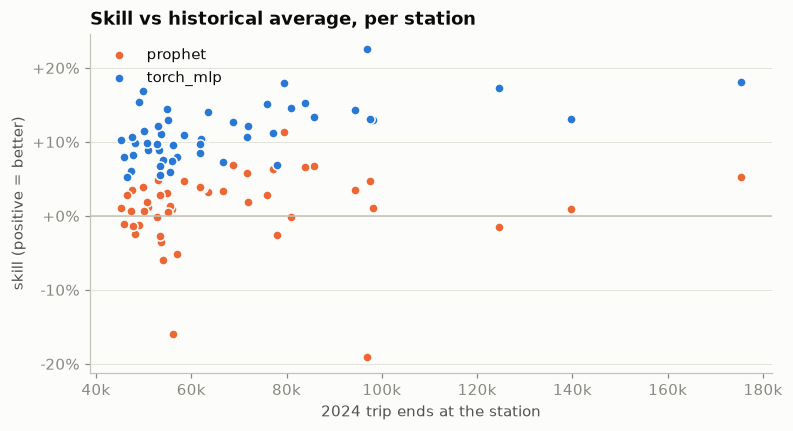

MLP beats the historical average at 50 of 50 stations; Prophet at 36.
Correlation of MLP skill with station volume: 0.57


,median skill_torch_mlp,median skill_prophet
volume_third,,
quietest,+9.7%,+1.1%
middle,+9.9%,+3.2%
busiest,+13.4%,+3.6%


In [2]:
scores = station_scores(preds, stations)
fig, ax = plt.subplots(figsize=(8, 4))
for m in ["prophet", "torch_mlp"]:
    ax.scatter(
        scores["rank_volume"],
        scores[f"skill_{m}"],
        s=36,
        color=COLORS[m],
        label=m,
        edgecolor=viz.SURFACE,
        linewidth=1,
    )
ax.axhline(0, color=viz.BASELINE, linewidth=1)
ax.set_title("Skill vs historical average, per station")
ax.set_xlabel("2024 trip ends at the station")
ax.set_ylabel("skill (positive = better)")
ax.yaxis.set_major_formatter(lambda v, _: f"{v:+.0%}")
ax.xaxis.set_major_formatter(lambda v, _: f"{v / 1000:g}k")
ax.legend(loc="upper left")
viz.save(fig, "errors_skill_by_station")
plt.show()

scores["volume_third"] = pd.qcut(scores["rank_volume"], 3, labels=["quietest", "middle", "busiest"])
summary = scores.groupby("volume_third", observed=True)[
    ["skill_torch_mlp", "skill_prophet"]
].median()
print(
    f"MLP beats the historical average at {(scores['skill_torch_mlp'] > 0).sum()} of "
    f"{len(scores)} stations; Prophet at {(scores['skill_prophet'] > 0).sum()}."
)
print(
    f"Correlation of MLP skill with station volume: "
    f"{scores['skill_torch_mlp'].corr(scores['rank_volume']):.2f}"
)
summary.map("{:+.1%}".format).rename(columns=lambda c: "median " + c)

## 2. When does each model fail? Error and bias by hour

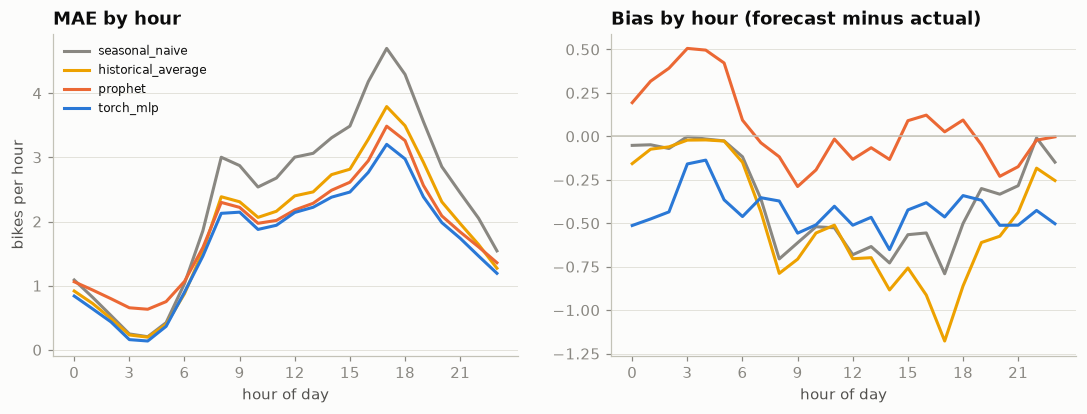

,mean bias
model,
seasonal_naive,-0.36 bikes/hour
historical_average,-0.48 bikes/hour
prophet,+0.05 bikes/hour
torch_mlp,-0.43 bikes/hour


In [3]:
mae_hour = (
    preds.groupby(["hour", "model"])
    .apply(lambda d: (d["y"] - d["yhat"]).abs().mean(), include_groups=False)
    .unstack("model")[MODELS]
)
bias = bias_by_hour(preds)[MODELS]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for m in MODELS:
    axes[0].plot(mae_hour.index, mae_hour[m], color=COLORS[m], label=m)
    axes[1].plot(bias.index, bias[m], color=COLORS[m], label=m)
axes[0].set_title("MAE by hour")
axes[1].set_title("Bias by hour (forecast minus actual)")
axes[1].axhline(0, color=viz.BASELINE, linewidth=1)
for ax in axes:
    ax.set_xlabel("hour of day")
    ax.set_xticks(range(0, 24, 3))
axes[0].set_ylabel("bikes per hour")
axes[0].legend(loc="upper left", fontsize=8)
viz.save(fig, "errors_by_hour")
plt.show()

overall_bias = preds.assign(e=preds["yhat"] - preds["y"]).groupby("model")["e"].mean()
overall_bias[MODELS].map("{:+.2f} bikes/hour".format).rename("mean bias").to_frame()

Negative bias means under-forecasting. The MLP was trained with L1 loss (chosen on validation every
week), which targets the median. For right-skewed counts the median sits below the mean, so a
median forecast under-counts totals. That matters for rebalancing, where totals are what count.

## 3. Breakdowns: weekday vs weekend, season, rain vs dry

In [4]:
def mae_by(col):
    t = (
        preds.groupby([col, "model"])
        .apply(lambda d: (d["y"] - d["yhat"]).abs().mean(), include_groups=False)
        .unstack("model")[MODELS]
    )
    t["MLP skill vs hist avg"] = (1 - t["torch_mlp"] / t["historical_average"]).map(
        "{:+.1%}".format
    )
    return t.round(3)


for col in ["day_type", "season", "weather"]:
    display(mae_by(col))

model,seasonal_naive,historical_average,prophet,torch_mlp,MLP skill vs hist avg
day_type,,,,,
weekday,2.275,1.872,1.835,1.621,+13.4%
weekend,2.444,1.935,1.930,1.770,+8.5%


model,seasonal_naive,historical_average,prophet,torch_mlp,MLP skill vs hist avg
season,,,,,
fall,3.016,2.415,2.342,1.968,+18.5%
spring,2.283,1.931,1.666,1.604,+17.0%
summer,2.555,1.988,2.123,1.920,+3.4%
winter,1.314,1.134,1.262,1.045,+7.9%


model,seasonal_naive,historical_average,prophet,torch_mlp,MLP skill vs hist avg
weather,,,,,
dry,2.264,1.853,1.838,1.689,+8.8%
rainy,2.454,1.969,1.916,1.608,+18.4%


## 4. Worst days per model, and what happened

In [5]:
daily = daily_errors(preds, weather)
for m in ["historical_average", "prophet", "torch_mlp"]:
    print(m)
    w = worst_days(daily, m, 5)[
        ["date", "weekday", "mae", "precip_mm", "holiday_name", "actual_trips"]
    ]
    display(w.assign(date=w["date"].dt.date).round(2))

historical_average


,date,weekday,mae,precip_mm,holiday_name,actual_trips
0,2025-10-13,Monday,4.27,30.6,Columbus Day,6704
1,2025-04-19,Saturday,3.77,2.2,<NA>,49392
2,2025-10-14,Tuesday,3.28,4.7,<NA>,23216
3,2026-03-10,Tuesday,2.71,0.0,<NA>,37128
4,2025-04-20,Sunday,2.70,0.0,<NA>,38192


prophet


,date,weekday,mae,precip_mm,holiday_name,actual_trips
0,2026-09-19,Saturday,2.79,0.0,<NA>,55336
1,2025-04-19,Saturday,2.76,2.2,<NA>,49392
2,2025-10-18,Saturday,2.74,0.0,<NA>,53532
3,2025-07-18,Friday,2.69,0.0,<NA>,52928
4,2025-10-14,Tuesday,2.61,4.7,<NA>,23216


torch_mlp


,date,weekday,mae,precip_mm,holiday_name,actual_trips
0,2025-04-19,Saturday,2.75,2.2,<NA>,49392
1,2025-10-18,Saturday,2.70,0.0,<NA>,53532
2,2025-07-20,Sunday,2.41,4.2,<NA>,38552
3,2025-07-18,Friday,2.34,0.0,<NA>,52928
4,2026-09-19,Saturday,2.30,0.0,<NA>,55336


In [6]:
# The two worst days for both learned models are Saturdays. Which stations missed most?
t = preds[preds["model"] == "torch_mlp"]
for day in ["2025-10-18", "2025-04-19"]:
    d = t[t["date"] == day].groupby("station_id")[["y", "yhat"]].sum()
    d["missed"] = d["y"] - d["yhat"]
    d["name"] = names[d.index]
    print(f"{day}: top-50 trips actual {d['y'].sum():,.0f}, MLP forecast {d['yhat'].sum():,.0f}")
    display(d.nlargest(5, "missed")[["name", "y", "yhat", "missed"]].round(0))

2025-10-18: top-50 trips actual 13,383, MLP forecast 8,596


,name,y,yhat,missed
station_id,,,,
M32038,Harvard University River Houses at DeWolfe St ...,685,177.0,508.0
M32006,MIT at Mass Ave / Amherst St,803,558.0,245.0
D32024,Beacon St at Charles St,409,187.0,222.0
M32017,Harvard Square at Brattle St / Eliot St,320,105.0,215.0
B32016,Beacon St at Massachusetts Ave,539,331.0,208.0


2025-04-19: top-50 trips actual 12,348, MLP forecast 8,243


,name,y,yhat,missed
station_id,,,,
B32016,Beacon St at Massachusetts Ave,736,296.0,440.0
M32006,MIT at Mass Ave / Amherst St,871,534.0,337.0
B32018,Boylston St at Massachusetts Ave,477,175.0,302.0
D32016,Charles Circle - Charles St at Cambridge St,501,219.0,282.0
D32017,Mugar Way at Beacon St,435,159.0,276.0


In [7]:
temp = weather.set_index("ts")["temp_c"].between_time("07:00", "20:00").resample("D").mean()
print("Daytime temperature, March 2026:", temp["2026-03-05":"2026-03-11"].round(1).to_dict())
daily.pivot_table(index="date", columns="model", values="mae").loc[
    ["2025-10-13", "2026-03-10"], MODELS
].round(2)

Daytime temperature, March 2026: {Timestamp('2026-03-05 00:00:00'): 1.6, Timestamp('2026-03-06 00:00:00'): 0.7, Timestamp('2026-03-07 00:00:00'): 3.9, Timestamp('2026-03-08 00:00:00'): 8.1, Timestamp('2026-03-09 00:00:00'): 10.7, Timestamp('2026-03-10 00:00:00'): 15.7, Timestamp('2026-03-11 00:00:00'): 6.9}


model,seasonal_naive,historical_average,prophet,torch_mlp
date,,,,
2025-10-13,4.61,4.27,1.89,1.07
2026-03-10,2.98,2.71,1.75,1.72


## 5. Worked example: Columbus Day 2025 at Kendall

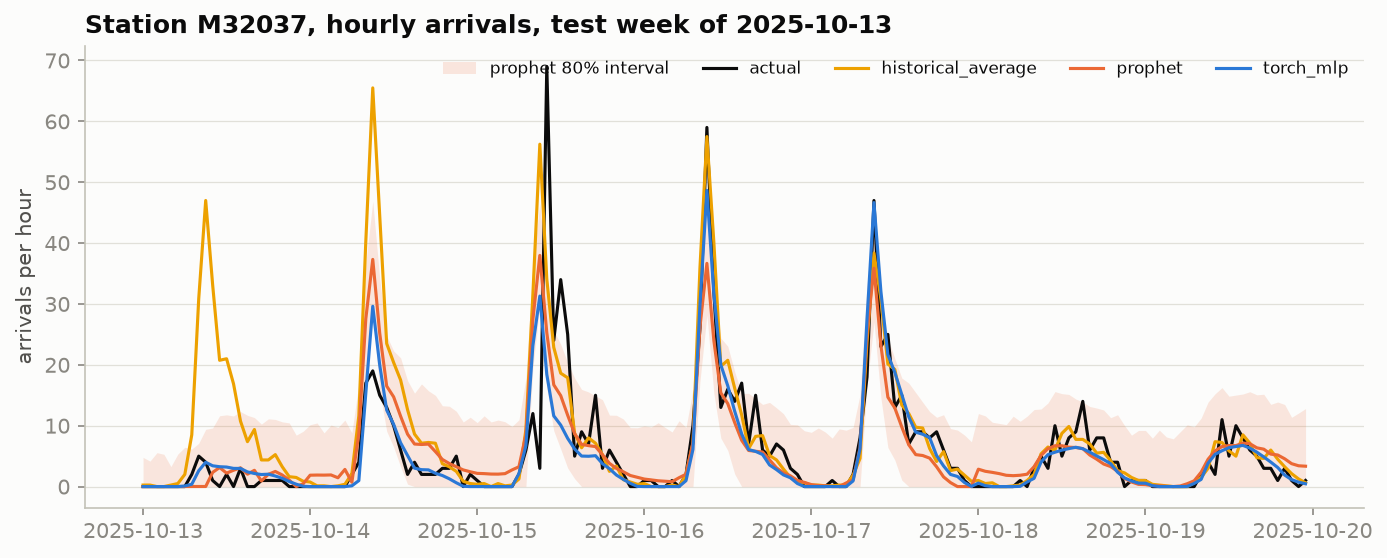

In [8]:
display(Image(filename=str(config.FIGURES / "results_spot_check.png")))

Monday 2025-10-13 was Columbus Day and also rained about 31 mm. The historical average copies a
normal Monday and forecasts a commute peak at Ames St that never comes. Prophet and the MLP both
know it is a holiday. Prophet's band is about the same width at 3am and at the 8am peak.

## 6. Structural breaks flagged in Phase 1

In [9]:
s = scores.copy()
s["relative_error"] = s["mae_torch_mlp"] / s["mean_actual"]
s["skill_rank_low_to_high"] = s["skill_torch_mlp"].rank()
s["relative_error_rank_high_to_low"] = s["relative_error"].rank(ascending=False)
s.loc[
    ["A32025", "D32005"],
    [
        "name",
        "skill_torch_mlp",
        "skill_rank_low_to_high",
        "relative_error",
        "relative_error_rank_high_to_low",
    ],
].round(3)

,name,skill_torch_mlp,skill_rank_low_to_high,relative_error,relative_error_rank_high_to_low
station_id,,,,,
A32025,Nashua Street at Red Auerbach Way,0.055,2.0,0.619,3.0
D32005,Copley Square - Dartmouth St at Boylston St,0.089,15.0,0.505,15.0


## 7. Prophet interval calibration by hour

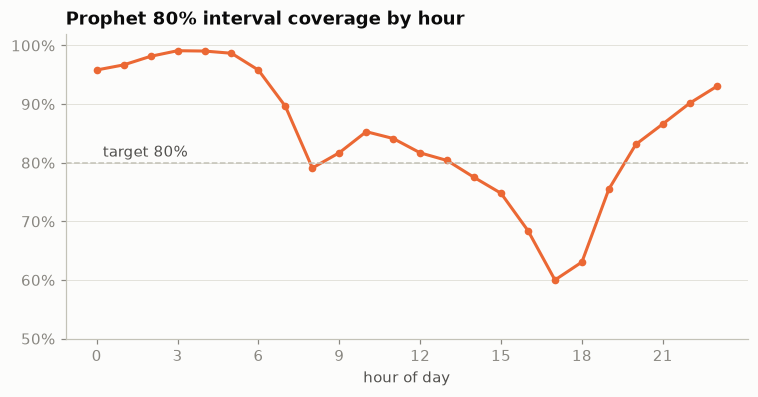

Lowest: 60.0% at 17:00. Highest: 99.1% at 3:00.


In [10]:
cov = coverage_by_hour(preds)
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(cov.index, cov.values, color=COLORS["prophet"], marker="o", markersize=4)
ax.axhline(0.8, color=viz.BASELINE, linewidth=1, linestyle="--")
ax.annotate("target 80%", (0, 0.8), xytext=(4, 4), textcoords="offset points", color=viz.INK_2)
ax.set_title("Prophet 80% interval coverage by hour")
ax.set_xlabel("hour of day")
ax.set_ylim(0.5, 1.02)
ax.set_xticks(range(0, 24, 3))
ax.yaxis.set_major_formatter(lambda v, _: f"{v:.0%}")
viz.save(fig, "errors_prophet_coverage")
plt.show()
print(
    f"Lowest: {cov.min():.1%} at {cov.idxmin()}:00. Highest: {cov.max():.1%} at {cov.idxmax()}:00."
)

## Findings (draft for Jason to confirm or edit)

1. **The MLP's gains are everywhere, and largest at busy stations.** It beats the historical average
   at all 50 stations (skill +5% to +23%, median about +11%). Skill rises with volume (correlation
   0.57): the busiest third gains about 13% vs about 10% for the quietest third. Prophet beats the
   historical average at only 36 of 50. The gain is smallest where leisure trips dominate: summer weeks (+3.4%)
   and weekends (+8.5%, vs +13.4% on weekdays). Commute demand is regular, so lags help most there.
2. **The biggest misses are crowd events, not weather.** The worst days for both the MLP and Prophet
   are Saturdays near the Charles River. On 2025-10-18, likely the Head of the Charles Regatta
   weekend, the Harvard River Houses station saw 685 trips against 177 forecast, and the top 50 had
   13.4k trips vs 8.6k forecast. On 2025-04-19, Boston Marathon weekend, the misses were at Back Bay
   and Esplanade stations. No model has an event feature; an event calendar is the clearest next step.
3. **Holidays and sudden weather changes break the simple baselines.** The historical average's worst
   day is Columbus Day 2025 (MAE 4.27 vs 1.07 for the MLP). On 2026-03-10, the first warm day of
   spring (15.7 C after a week near freezing), the historical average and seasonal naive miss badly
   while Prophet and the MLP, which see the weather forecast, do much better.
4. **Most models under-forecast, the MLP by design.** Mean bias is about -0.43 bikes/hour for the MLP,
   fairly steady through the day, because L1 loss targets the median. The historical average
   under-forecasts most at the 5pm peak (about -1.2). Prophet is nearly unbiased overall (+0.05) but
   over-forecasts at night (about +0.5 at 3am), the additive-seasonality problem from Phase 2. Any total built from MLP forecasts, like bikes to move, will run low, so the rebalancing
   estimate is checked against actuals.
5. **Structural breaks show up where expected.** Nashua St (A32025), which got a new dock next door in
   April 2025, has the second-lowest MLP skill of all 50 stations. Copley (D32005) sits mid-pack, so its
   new neighbor in May 2024 (before every test week) seems to have been absorbed into training.
6. **Prophet's intervals are right on average but wrong by hour**: about 99% coverage at 3am and about
   60% at 5pm. Its noise model assumes the same spread at every hour.